# Convolution Neural Networks

## Designing a CNN model

In [12]:
import torch
import torchvision
from torchvision import datasets
from torch import nn
import torch.nn.functional as F


Implementation of Simple Convolution Neural Network. This is actually the AlexNet architecture. But the classifier is different as here we are using only two classes. 

In [13]:
class CNNNet(nn.Module):
    def __init__(self,num_classes=2):
        super(CNNNet,self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,64,kernel_size=11, stride=4, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6,6))
        self.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(256*6*6,4096),
            nn.ReLU(),
            nn.Dropout(),
            nn.Linear(4096,4096),
            nn.ReLU(),
            nn.Linear(4096,num_classes)
        )

    def forward(self,x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x,1)
        x=self.classifier(x)

        return x

Let's try out our CNN for Images Classification task.  
We will use the model traininf function implemented in the previous notebook(ImageClassifier).

In [15]:
import torchvision
from torchvision import transforms
from torch.utils import data

transforms= transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229, 0.224, 0.225])
])

dataset = torchvision.datasets.CIFAR10(root='kaggle/input', 
                                        train=True, 
                                        download=True,
                                         transform=transforms)

test_dataset = torchvision.datasets.CIFAR10(root='kaggle/input', 
                                        train=False, 
                                        download=True,
                                        transform=transforms)



# Define the sizes for the split (80% train, 20% validation)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

# Set a seed for reproducibility
torch.manual_seed(42)

# Perform the split
train_dataset, val_dataset = data.random_split(dataset, [train_size, val_size])

# Print the sizes of each dataset to verify
print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Training set size: 40000
Validation set size: 10000
Test set size: 10000


In [21]:
batch_size=256
train_data_loader= data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_data_loader= data.DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
test_data_loader= data.DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [57]:
import torch.optim as optim
from tqdm import tqdm



def train_model(model,optimizer,loss_fn,train_loader,val_loader,epochs=20,device='cpu'):
    best_val_loss = float('inf')
    best_model=None
    for epoch in range(epochs):
        train_loss = 0.0
        val_loss = 0.0
        model.train()
        for batch in tqdm(train_loader):
            optimizer.zero_grad()
            inputs,target=batch
            inputs=inputs.to(device)
            target=target.to(device)
            output = model(inputs)
            loss = loss_fn(output,target)
            loss.backward()
            optimizer.step()
            train_loss+=loss.data.item()*inputs.size(0)
        train_loss/=len(train_loader.dataset)

        model.eval()
        num_correct=0
        num_examples=0
        with torch.no_grad():
            for batch in tqdm(val_loader):
                inputs,target=batch
                inputs=inputs.to(device)
                target=target.to(device)
                output = model (inputs)
                loss = loss_fn (output,target)
                val_loss+=loss.data.item()*inputs.size(0)
                predicted = torch.argmax(output, dim=1)
                num_correct += (predicted == target).sum().item()
                num_examples += len(target)
        val_loss/=len(val_loader.dataset)
        accuracy = num_correct/num_examples


        print('Epoch: {} , Training loss: {:.2f}, Validation loss: {:.2f}, accuracy: {:.2f}'.format(epoch,train_loss,val_loss,accuracy))




In [23]:
model = CNNNet(num_classes=10)
model.to('cuda')

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
epochs = 20

In [24]:
train_model(model,optimizer,loss_fn,train_data_loader,val_data_loader,epochs=epochs,device='cuda')

100%|██████████| 40/40 [00:15<00:00,  2.51it/s]


Epoch: 0 , Training loss: 1.75, Validation loss: 1.48, accuracy: 0.47


100%|██████████| 40/40 [00:15<00:00,  2.54it/s]


Epoch: 1 , Training loss: 1.35, Validation loss: 1.23, accuracy: 0.56


100%|██████████| 40/40 [00:15<00:00,  2.52it/s]


...

Epoch: 17 , Training loss: 0.18, Validation loss: 0.63, accuracy: 0.81


100%|██████████| 40/40 [00:15<00:00,  2.53it/s]


Epoch: 18 , Training loss: 0.16, Validation loss: 0.62, accuracy: 0.81


100%|██████████| 40/40 [00:15<00:00,  2.52it/s]

Epoch: 19 , Training loss: 0.14, Validation loss: 0.64, accuracy: 0.82


In [ ]:
torch.save(model.state_dict(),"models/CNN")   #saving the model params

Let's Load the saved model and our dataset

In [14]:
import torch
from torch.utils import data
import torchvision
from torchvision import transforms

model = CNNNet(num_classes=10)
model.load_state_dict(torch.load("models/CNN"))


transforms= transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229, 0.224, 0.225])
])

test_dataset = torchvision.datasets.CIFAR10(root='kaggle/input', 
                                        train=False, 
                                        download=True,
                                        transform=transforms)

test_data_loader= data.DataLoader(test_dataset, batch_size=64, shuffle=True)


Now we can test our model on set of sample Images

In [15]:
import torch
import numpy as np
import matplotlib.pyplot as plt

cifar10_classes = ('plane', 'car', 'bird', 'cat', 'deer', 
                   'dog', 'frog', 'horse', 'ship', 'truck')

def visualize_model_predictions(model, test_loader, device, num_images=16):
    """
    Visualizes model predictions on a batch of images from the test set.

    Args:
        model (torch.nn.Module): The trained PyTorch model.
        test_loader (torch.utils.data.DataLoader): DataLoader for the test set.
        device (str): The device to run the model on ('cuda' or 'cpu').
        num_images (int): The number of images to display. Must be a perfect square.
    """
    # Ensure the model is in evaluation mode
    model.eval()
    
    # Get a single batch of test images and labels
    images, labels = next(iter(test_loader))
    
    # Move images and labels to the correct device
    images = images.to(device)
    labels = labels.to(device)
    
    # Get model predictions
    with torch.no_grad():
        outputs = model(images)
    
    # Get the predicted class index by finding the max logit
    _, predicted = torch.max(outputs, 1)
    
    # Move data back to CPU for visualization with numpy/matplotlib
    images = images.cpu()
    predicted = predicted.cpu()
    labels = labels.cpu()
    
    # --- Plotting the images with their labels ---
    
    # Calculate grid size (e.g., for 16 images, we want a 4x4 grid)
    grid_size = int(np.sqrt(num_images))
    if grid_size**2 != num_images:
        print(f"Warning: num_images ({num_images}) is not a perfect square. "
              f"Plotting might be incomplete.")
        # Adjust to the largest possible square grid
        num_images = grid_size**2

    fig = plt.figure(figsize=(10, 10))
    
    for i in range(num_images):
        ax = fig.add_subplot(grid_size, grid_size, i + 1, xticks=[], yticks=[])
        
        # Un-normalize and display the image
        img = unnormalize(images[i])
        plt.imshow(img)
        
        # Set the title for each image
        # The color will be green for correct predictions and red for incorrect ones
        ax.set_title(
            f"Pred: {cifar10_classes[predicted[i].item()]}\n"
            f"(True: {cifar10_classes[labels[i].item()]})",
            color=("green" if predicted[i] == labels[i] else "red")
        )
        
    plt.tight_layout()
    plt.show()

def unnormalize(tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    """
    Reverses the normalization on an image tensor.
    
    Args:
        tensor (torch.Tensor): The normalized image tensor (C, H, W).
    
    Returns:
        numpy.ndarray: The un-normalized image suitable for display.
    """
    # Clone the tensor to avoid modifying the original
    tensor = tensor.clone() 
    
    # Apply the reverse transformation
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
        
    # Transpose the image from (C, H, W) to (H, W, C) for matplotlib
    return tensor.permute(1, 2, 0).numpy()

In [17]:
model.to('cuda')

CNNNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4)

Now Let's take a glance at the design of popular architectures 

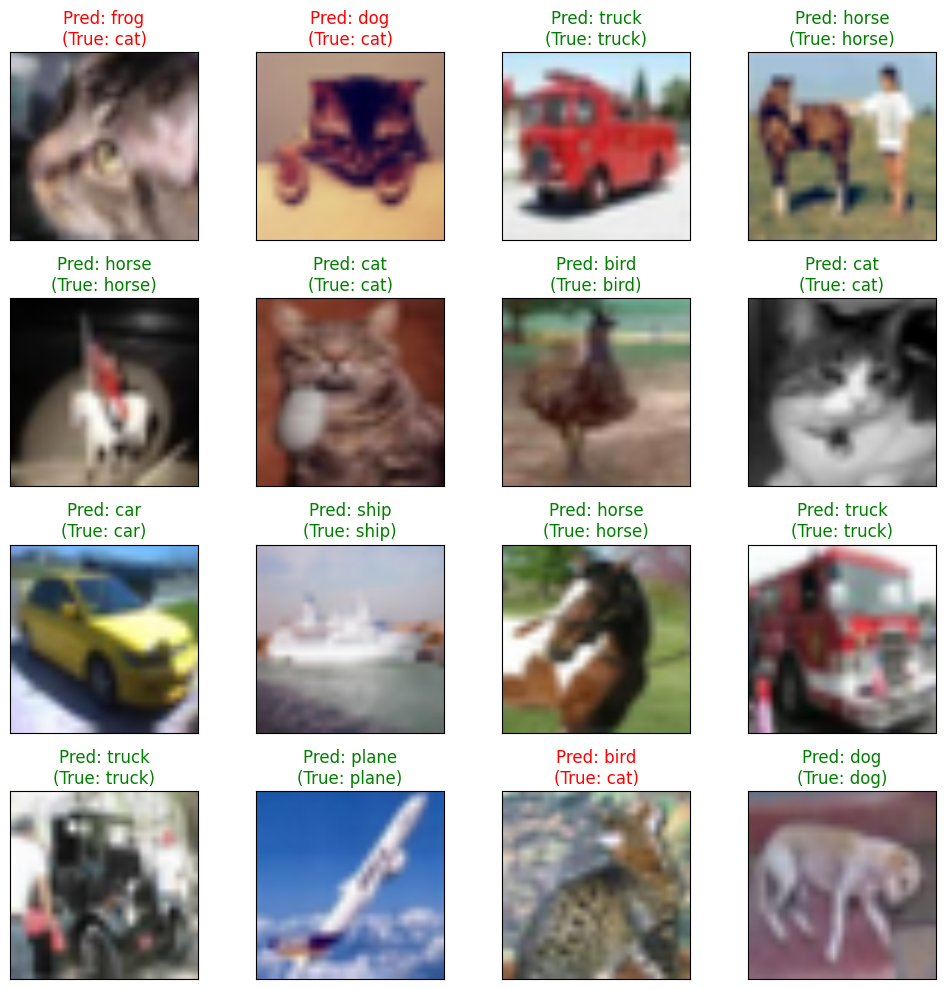

In [20]:
visualize_model_predictions(model, test_data_loader, 'cuda', num_images=16)

In [1]:
import torchvision.models as models 

In [2]:
print(models.resnet50())

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
print(models.mobilenet_v2())

In [ ]:
print(models.googlenet(init_weights = True))

In [ ]:
print(models.vgg16())

In [ ]:
import torch
torch.hub.list('pytorch/vision')

## Transfer Learning  

Those popular architectures are trained on larger datasets and capable of extracting features well. So here we will load ResNet with pre-trained weights and then adopt it for our task by fine tuning the parameters.  
Also if we were to train those large models ourselves it would take lot of resources.

In [63]:
from torchvision import models

transfer_model = models.resnet50(pretrained=True)

We not necessarilly train all the parameters as they are already good at feature extraction. So we will freeze parameters. Then we need to replace the classifier box for our task. Here we will use cats and dogs dataset with 2 classes.

Let's have a look at the model structure before freezing the layers.

In [64]:
from torchsummary import summary
transfer_model.to('cuda')
summary(transfer_model,(3,224,224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

As we can see all the parameters are trainable here. Now let's see what happens after freezing.

In [65]:
for name,param in transfer_model.named_parameters():
    if('bn' not in name):
        param.requires_grad = False     #not freezing batchnorm layers

In [66]:
summary(transfer_model,(3,224,224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

Now most of the parameters are not trainable.

We also need to replace the classifier block as the number of classes are different. From the Resnet 50 architecture we have looked at above, it has a fully connected layer at the end.  
```  (fc): Linear(in_features=2048, out_features=1000, bias=True) ```  
We will replace that fc layer to output 2 features.

In [67]:
import torch.nn as nn

transfer_model.fc = nn.Sequential(
                    nn.Linear(transfer_model.fc.in_features,500),
                    nn.ReLU(),
                    nn.Dropout(),
                    nn.Linear(500,2)
)

transfer_model.to('cuda')

summary(transfer_model,(3,224,224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

In [68]:
unfreeze_layers = [transfer_model.layer3, transfer_model.layer4]
for layer in unfreeze_layers:
    for name,param in layer.named_parameters():
        param.requires_grad = True
        

In [69]:
summary(transfer_model,(3,224,224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

First we will test the model with existing parameters and see how it works

In [70]:
import torchvision
from torchvision import transforms
from torch.utils import data 


test_data_path="/kaggle/input/cat-and-dog-finder/test_set/test_set"
train_data_path = "/kaggle/input/cat-and-dog-finder/training_set/training_set"

transforms= transforms.Compose([
    transforms.Resize((224,224)),          #Resize the image to 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229, 0.224, 0.225])
])

test_dataset=torchvision.datasets.ImageFolder(root=test_data_path,transform=transforms)
trainset=torchvision.datasets.ImageFolder(root=train_data_path,transform=transforms)

train_size = int(0.8 * len(trainset))
val_size = len(trainset) - train_size

# Set a seed for reproducibility
torch.manual_seed(42)

# Perform the split
train_dataset, val_dataset = data.random_split(trainset, [train_size, val_size])



In [71]:
batch_size=64

train_data_loader= data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_data_loader= data.DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
test_data_loader= data.DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [72]:
import torch
import torch.nn as nn

class_names = ('cat', 'dog')

def test_model_accuracy(model, test_loader, device):
    """
    Calculates the overall accuracy and per-class accuracy of a model on the test set.

    Args:
        model (torch.nn.Module): The trained PyTorch model.
        test_loader (torch.utils.data.DataLoader): DataLoader for the test set.
        device (str): The device to run the model on ('cuda' or 'cpu').
    """
    # Ensure the model is in evaluation mode
    model.eval()
    
    correct = 0
    total = 0
    
    # Initialize per-class accuracy tracking
    num_classes = len(class_names)
    class_correct = list(0. for i in range(num_classes))
    class_total = list(0. for i in range(num_classes))
    
    # Disable gradient calculations for efficiency
    with torch.no_grad():
        # Iterate over the entire test dataset
        for images, labels in test_loader:
            # Move images and labels to the correct device
            images = images.to(device)
            labels = labels.to(device)
            
            # Get model predictions (logits)
            outputs = model(images)
            
            # Get the predicted class index by finding the max logit
            _, predicted = torch.max(outputs.data, 1)
            
            # Update total and correct counts for overall accuracy
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            # Update per-class accuracy counts
            c = (predicted == labels).squeeze()
            # Handle cases where the batch size is 1
            if c.dim() == 0:
                c = c.unsqueeze(0)
                
            for i in range(len(labels)):
                label = labels[i]
                class_correct[label] += c[i].item()
                class_total[label] += 1

    # --- Print the results ---
    
    # Calculate and print overall accuracy
    overall_accuracy = 100 * correct / total
    print(f'Accuracy of the model on the {total} test images: {overall_accuracy:.2f} %')
    print('-' * 50)

    # Calculate and print the accuracy for each class
    for i in range(num_classes):
        if class_total[i] > 0:
            class_accuracy = 100 * class_correct[i] / class_total[i]
            print(f'Accuracy of {class_names[i]:>10s} : {class_accuracy:.2f} %')
        else:
            print(f'Accuracy of {class_names[i]:>10s} : N/A (no samples)')



In [73]:
device = 'cuda'
transfer_model.to(device) 
test_model_accuracy(transfer_model, test_data_loader, device)

Accuracy of the model on the 2023 test images: 50.17 %
--------------------------------------------------
Accuracy of        cat : 5.64 %
Accuracy of        dog : 94.66 %


As we can see the results are awful. That is because we changed the model architecture but did not trained the parameters. now let's train the model parameters. Let's setup different learning rates for different layers.

In [74]:
import torch.optim as optimizer

lr = 0.001

optimizer = optimizer.Adam([
    {'params' : transfer_model.layer4.parameters(), 'lr' : lr/3},
    {'params' : transfer_model.layer3.parameters(), 'lr' : lr/9},
    ], lr = lr)

In [75]:
loss_fn = nn.CrossEntropyLoss()

Everything is ready. Now let's train our model.

In [76]:
train_model(transfer_model,optimizer,loss_fn,train_data_loader,val_data_loader,epochs=3,device='cuda')

100%|██████████| 26/26 [00:11<00:00,  2.28it/s]


Epoch: 0 , Training loss: 0.09, Validation loss: 0.06, accuracy: 0.98


100%|██████████| 26/26 [00:11<00:00,  2.22it/s]


Epoch: 1 , Training loss: 0.03, Validation loss: 0.04, accuracy: 0.99


100%|██████████| 26/26 [00:11<00:00,  2.24it/s]

Epoch: 2 , Training loss: 0.02, Validation loss: 0.04, accuracy: 0.99


We are done with fine tuning the parameters. Now let's check the performance of our model.

In [78]:
transfer_model.to('cuda') 
transfer_model.eval()
test_model_accuracy(transfer_model, test_data_loader, device)

Accuracy of the model on the 2023 test images: 98.52 %
--------------------------------------------------
Accuracy of        cat : 99.70 %
Accuracy of        dog : 97.33 %


As you can see it has worked like a charm. let's try visualizing some of the results.

In [79]:
import numpy as np
import matplotlib.pyplot as plt

dataset_classes = ('cat','dog')

def visualize_model_predictions(model, test_loader, device, num_images=16):
    """
    Visualizes model predictions on a batch of images from the test set.

    Args:
        model (torch.nn.Module): The trained PyTorch model.
        test_loader (torch.utils.data.DataLoader): DataLoader for the test set.
        device (str): The device to run the model on ('cuda' or 'cpu').
        num_images (int): The number of images to display. Must be a perfect square.
    """
    # Ensure the model is in evaluation mode
    model.eval()
    
    # Get a single batch of test images and labels
    images, labels = next(iter(test_loader))
    
    # Move images and labels to the correct device
    images = images.to(device)
    labels = labels.to(device)
    
    # Get model predictions
    with torch.no_grad():
        outputs = model(images)
    
    # Get the predicted class index by finding the max logit
    _, predicted = torch.max(outputs, 1)
    
    # Move data back to CPU for visualization with numpy/matplotlib
    images = images.cpu()
    predicted = predicted.cpu()
    labels = labels.cpu()
    
    # --- Plotting the images with their labels ---
    
    # Calculate grid size (e.g., for 16 images, we want a 4x4 grid)
    grid_size = int(np.sqrt(num_images))
    if grid_size**2 != num_images:
        print(f"Warning: num_images ({num_images}) is not a perfect square. "
              f"Plotting might be incomplete.")
        # Adjust to the largest possible square grid
        num_images = grid_size**2

    fig = plt.figure(figsize=(10, 10))
    
    for i in range(num_images):
        ax = fig.add_subplot(grid_size, grid_size, i + 1, xticks=[], yticks=[])
        
        # Un-normalize and display the image
        img = unnormalize(images[i])
        plt.imshow(img)
        
        # Set the title for each image
        # The color will be green for correct predictions and red for incorrect ones
        ax.set_title(
            f"Pred: {dataset_classes[predicted[i].item()]}\n"
            f"(True: {dataset_classes[labels[i].item()]})",
            color=("green" if predicted[i] == labels[i] else "red")
        )
        
    plt.tight_layout()
    plt.show()

def unnormalize(tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
    """
    Reverses the normalization on an image tensor.
    
    Args:
        tensor (torch.Tensor): The normalized image tensor (C, H, W).
    
    Returns:
        numpy.ndarray: The un-normalized image suitable for display.
    """
    # Clone the tensor to avoid modifying the original
    tensor = tensor.clone() 
    
    # Apply the reverse transformation
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
        
    # Transpose the image from (C, H, W) to (H, W, C) for matplotlib
    return tensor.permute(1, 2, 0).numpy()

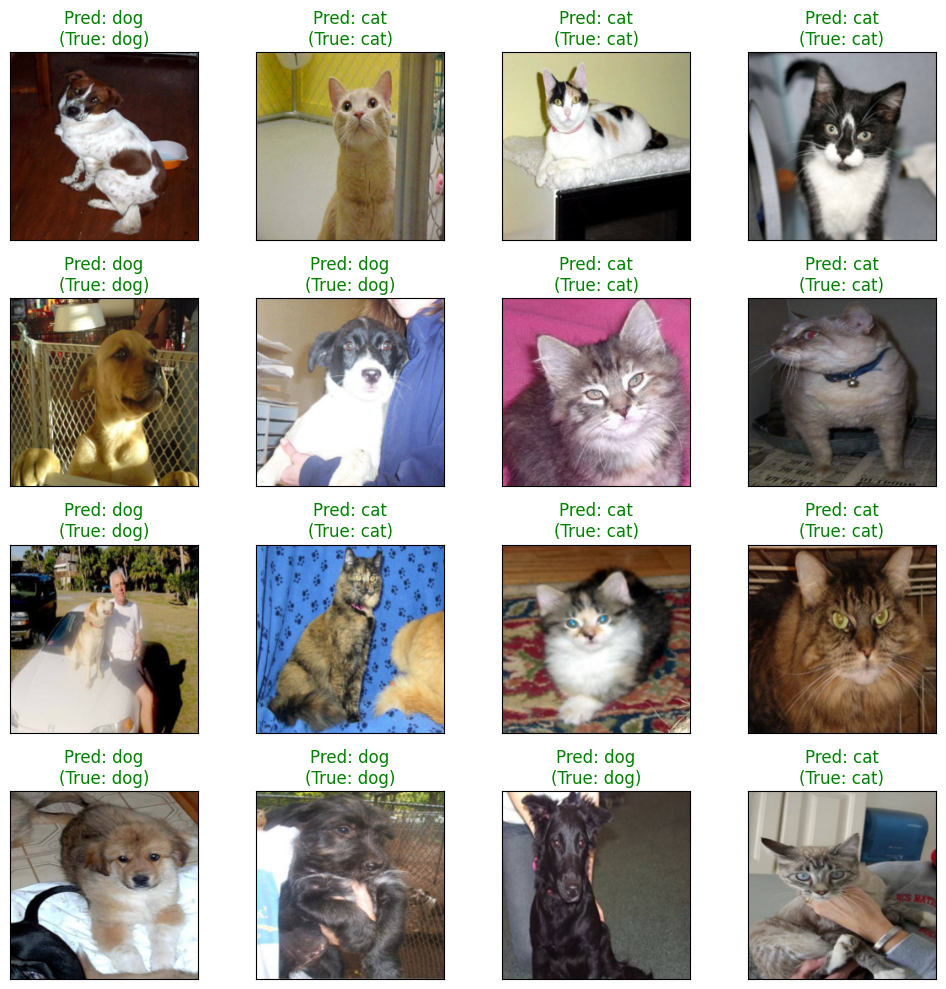

In [82]:
visualize_model_predictions(transfer_model, test_data_loader, 'cuda', num_images=16)

Well that's it. I have created seperate notebook on learning rate but I think It should be included somewhere inside this and I'll look in to that later. Next lets move into the domain of NLP